In [1]:
# pylint: disable=duplicate-code

In [2]:
# If spaCy model is missing:
# !python -m spacy download en_core_web_sm

In [3]:
%load_ext autoreload
%autoreload 2
%config InlineBackend.figure_format = "retina"


In [4]:
import warnings

warnings.filterwarnings("ignore", category=FutureWarning)

In [ ]:
import sys
from pathlib import Path

# Make sure `experiments/analysis` is on sys.path, so `import src.*` works
cwd = Path.cwd().resolve()
candidates = [cwd, *cwd.parents]
analysis_dir = None
for p in candidates:
    if (p / "experiments" / "analysis" / "src").exists():
        analysis_dir = p / "experiments" / "analysis"
        break
    if (p / "src").exists() and p.name == "analysis":
        analysis_dir = p
        break
if analysis_dir is None:
    raise RuntimeError("Could not locate experiments/analysis directory for imports.")
sys.path.insert(0, str(analysis_dir))

In [6]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

sns.set_style("whitegrid")

In [7]:
from IPython.display import display
from src.common import SV_COL, get_all_modes_df, set_mode_category
from src.linguistic import ROOT_DEP, enrich, get_linguistic_stats, get_nlp, map_subwords_to_tokens
from src.multi_sentence import FIGURES_DIR, STATS_DIR, get_multi_sentence_df
from src.plots import plot_attribution_trend, plot_importance_cumsum_and_derivative, plot_token_count_distribution
from src.stats import AGG_DICT, perform_advanced_ttest
from src.transformations import calculate_normalized_entropy, normalize_lengths

# Multi-sentence analysis (SGPA=True)

This notebook mirrors the single-sentence analysis style, but is adapted for the *multi_sentence* dataset:
- prompts can span multiple user turns
- we also analyze *sentence-level* attribution (sentences ≠ turns)
- we include audio/text interaction proxies for interleaved prompts.

We only use **SGPA=True** because the SGPA=False run is missing samples for some cases.


In [8]:
df_full = get_multi_sentence_df()
df = df_full[df_full["sgpa"] == True].copy()  # noqa: E712  pylint: disable=singleton-comparison

print(df_full.groupby(["sgpa", "mode"]).size().unstack(fill_value=0))
print("rows (sgpa=True):", len(df))

mode   IAF_SM2T  ITF_SM2T  SM2T  T2T
sgpa                                
True        100       100   100  100
False       100       100    34  100
rows (sgpa=True): 400


In [9]:
# Basic integrity: for each row_index we expect a consistent set of modes (within SGPA=True)
mode_counts = df.groupby("row_index")["mode"].nunique()
if mode_counts.nunique() != 1:
    raise RuntimeError("Missing data for some row_index in SGPA=True subset.")
df.head(2)

,row_index,tokens,sv,inputs,count_explainable_tokens,mode,sgpa,neyman_steps,n_calls,runtime_sec,raw_model_response,language,prompt_texts,input_modality,output_modality
0,63,"[Write, a, song, about, innovation, with,...","[0.04972367361187935, 0.011676877737045288, 0....",Write a song about innovation with a positive ...,22,T2T,True,2,1100,443.941294,"<|im_start|>assistant\n""Imagine a world where ...",en,[Write a song about innovation with a positive...,text,text
1,22,"[What, is, L, IL, O, and, GR, UB, used, ...","[0.03894412890076637, 0.043076980859041214, 0....",What is LILO and GRUB used for in Linux system...,19,T2T,True,2,804,337.019043,<|im_start|>assistant\nLILO and GRUB are two e...,en,[What is LILO and GRUB used for in Linux syste...,text,text


# Data distributions


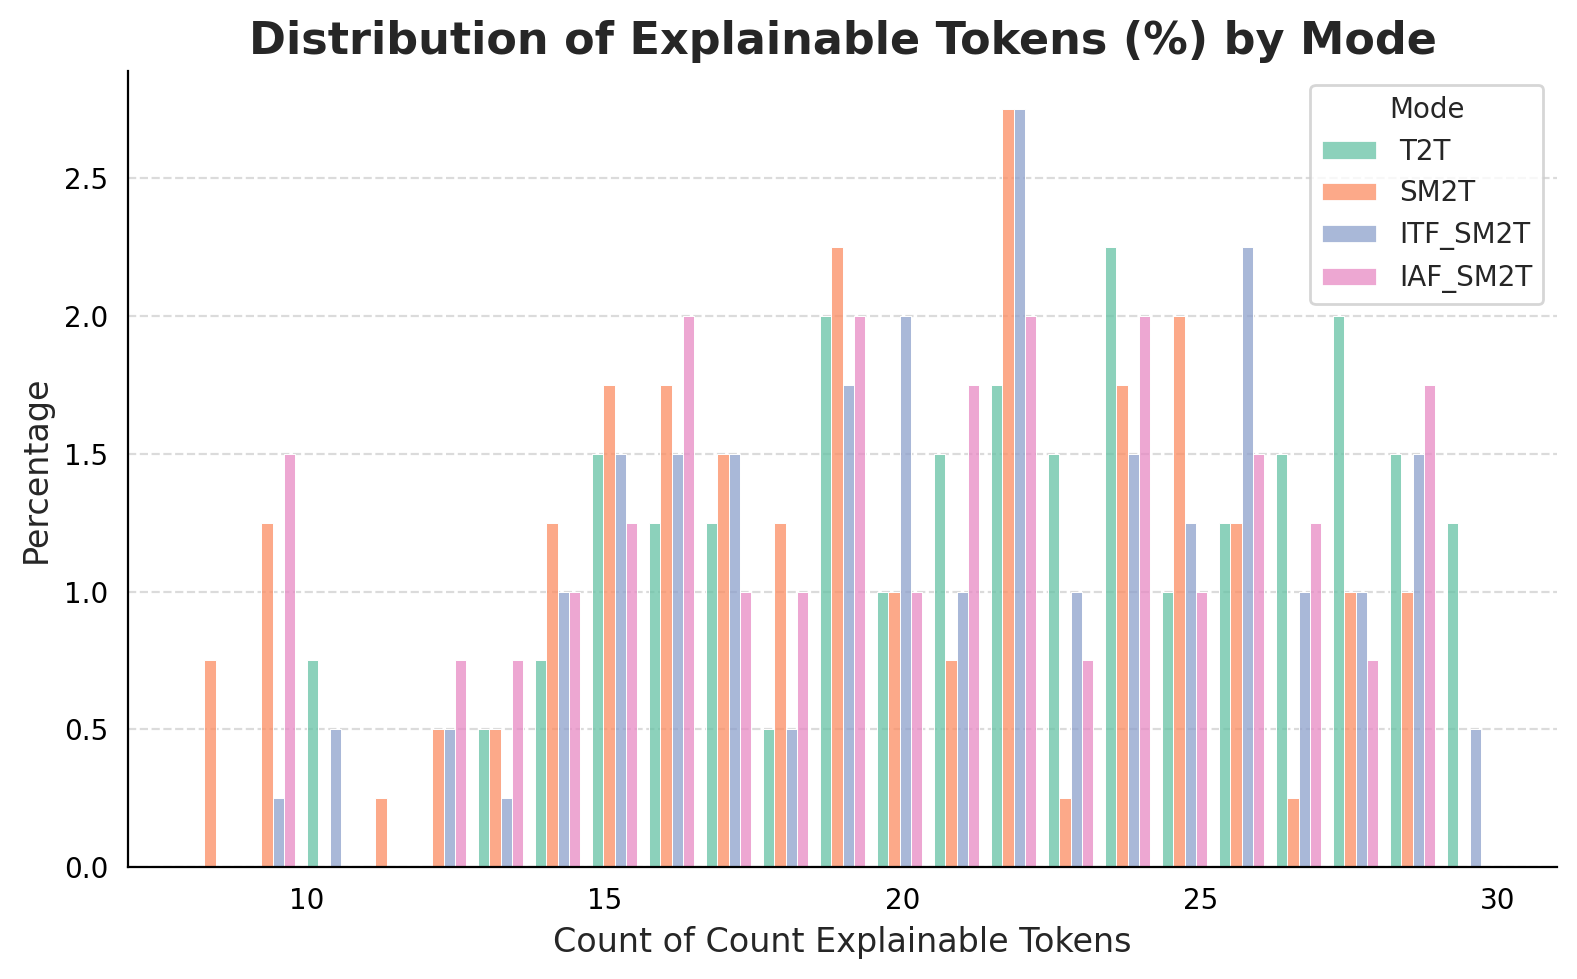

In [10]:
plot_token_count_distribution(df.rename(columns={"mode": "Mode"}), column="count_explainable_tokens", hue="Mode")
plt.savefig(f"{FIGURES_DIR}/token_count_distribution.png", bbox_inches="tight", dpi=300)

In [11]:
neyman_steps_distribution = df.groupby("mode")["neyman_steps"].value_counts(normalize=True)
neyman_steps_distribution.unstack()

neyman_steps,2
mode,
IAF_SM2T,1.0
ITF_SM2T,1.0
SM2T,1.0
T2T,1.0


In [12]:
summary_stats = df.groupby("mode")[["n_calls", "runtime_sec"]].agg(["describe"])
summary_stats.stack(level=0).unstack(level=1)

describe                                                           \
            count                 mean                     std               
          n_calls runtime_sec  n_calls runtime_sec     n_calls runtime_sec   
mode                                                                         
IAF_SM2T    100.0       100.0  1003.32  384.930607  533.693834  206.209165   
ITF_SM2T    100.0       100.0  1085.26  425.544568  520.896558  201.316043   
SM2T        100.0       100.0   925.96  364.937907  513.285947  199.750690   
T2T         100.0       100.0  1175.04  451.095979  550.881496  211.162842   

                                                                              \
             min                 25%                 50%                 75%   
         n_calls runtime_sec n_calls runtime_sec n_calls runtime_sec n_calls   
mode                                                                           
IAF_SM2T   152.0   53.373590   557.5  229.959861   991.0  350.446831  1362.5   
ITF_SM2T   156.0   66.851073   629.5  258.727896  1098.0  386.274421  1484.0   
SM2T       120.0   46.932554   533.5  221.536108   807.0  336.990652  1331.5   
T2T        194.0   70.484976   715.5  270.062455  1113.0  431.775030  1625.0   

                                          
                         max              
         runtime_sec n_calls runtime_sec  
mode                                      
IAF_SM2T  524.962169  2010.0  840.075777  
ITF_SM2T  581.266058  2160.0  845.751305  
SM2T      491.934585  2014.0  817.372159  
T2T       599.259406  2170.0  961.501674

In [14]:
# Quick sanity: show a few prompts/responses
for pt, rmr in df[df["mode"] == "T2T"][["inputs", "raw_model_response"]].head(3).itertuples(index=False):
    print(pt)
    print("\t- " + str(rmr).replace("\n", "\\n"))

Write a song about innovation with a positive tone that is appealing to teenagersPut your entire response in double quotation marks
	- <|im_start|>assistant\n"Imagine a world where every idea is a seed, every challenge a chance to grow, and every dream a stepping stone to the future. Innovation isn<|im_end|>\n
What is LILO and GRUB used for in Linux systemDescribes each in details。
	- <|im_start|>assistant\nLILO and GRUB are two essential components in the Linux kernel that manage the boot process and the initialization of the system.\n\n**L<|im_end|>\n
Write a limerick about writing a limerickDo not use any commas in your entire reply
	- <|im_start|>assistant\nI once wrote a limerick\nwith a rhyme and a rhyme\nI tried to rhyme with a rhyme\nbut I missed<|im_end|>\n


# Linguistic enrichment (token-level)
We compute spaCy token stats on the full concatenated prompt text (English).


In [15]:
df["linguistic_stats"] = df["inputs"].apply(lambda s: get_linguistic_stats(s, language="en"))
df["stats_mapping"] = df.apply(
    lambda row: map_subwords_to_tokens(
        row["tokens"],
        [stat["text"] for stat in row["linguistic_stats"]],
        language="en",
    ),
    axis=1,
)
if not (df["stats_mapping"].apply(len) == df["tokens"].apply(len)).all().item():
    raise RuntimeError("Subword to token mapping length mismatch.")
results_df = enrich(df)
results_df.head(2)

,prompt,row_index,mode,language,token,id,sv,dep,pos,children,importance,group
0,Write a song about innovation with a positive ...,63,T2T,en,Write,0,0.049724,ROOT,VERB,2,1.0,core_structure
1,Write a song about innovation with a positive ...,63,T2T,en,a,1,0.011677,det,DET,0,5.0,function_words


In [16]:
# Convenience columns
results_df["abs_sv"] = results_df[SV_COL].abs()
results_df["is_audio"] = results_df["token"].astype(str).str.contains(r"AUDIO_", regex=True)
results_df["is_text"] = ~results_df["is_audio"]
text_results_df = results_df[results_df["is_text"]].copy()
text_results_df.shape

(4390, 15)

In [17]:
# Aggregate-mode flags (same idea as single_sentence)
additional_modes = ["S2S", "S2T", "S2*", "T2*", "*2T", "*2S"]
modes_order = ["ALL", "T2*", "S2*", "*2T", "*2S", "T2T", "SM2T", "ITF_SM2T", "IAF_SM2T"]

results_df["T2*"] = results_df["mode"] == "T2T"
results_df["S2T"] = results_df["mode"].isin(["SM2T", "ITF_SM2T", "IAF_SM2T"])
results_df["S2S"] = False
results_df["S2*"] = results_df["S2T"] | results_df["S2S"]
results_df["*2T"] = results_df["T2*"] | results_df["S2T"]
results_df["*2S"] = False

all_modes_results_df = get_all_modes_df(results_df, additional_modes=additional_modes)
all_modes_results_df = set_mode_category(all_modes_results_df, modes_order)

# Base tests (multimodality focus)


In [18]:
def filter_results(_df: pd.DataFrame) -> pd.DataFrame:
    """Keep only significant adjusted p-values and core columns."""
    if _df is None or _df.empty:
        return pd.DataFrame()
    cols = ["metric", "Mode_1", "Mode_2", "P_Value", "Significant_Adj", "Sample_Size"]
    cols = [c for c in cols if c in _df.columns]
    out = _df[_df["Significant_Adj"]].copy()
    return out[cols].sort_values(by=["metric", "Mode_1", "Mode_2"]).reset_index(drop=True)

In [19]:
results = perform_advanced_ttest(
    results_df,
    grp_by_cols=["row_index", "mode"],
    value_col=SV_COL,
)
results.to_csv(f"{STATS_DIR}/mean_ttest_results.csv", index=False)
display(filter_results(results).head(50))

,metric,Mode_1,Mode_2,P_Value,Significant_Adj,Sample_Size
0,gini,SM2T,T2T,<0.01,True,100
1,mean,IAF_SM2T,ITF_SM2T,<0.01,True,100
2,mean,IAF_SM2T,SM2T,<0.01,True,100
3,mean,IAF_SM2T,T2T,<0.01,True,100
4,mean,ITF_SM2T,SM2T,<0.01,True,100
5,mean,ITF_SM2T,T2T,<0.01,True,100
6,mean,SM2T,T2T,<0.01,True,100


## Entropy (token-level SV spread)


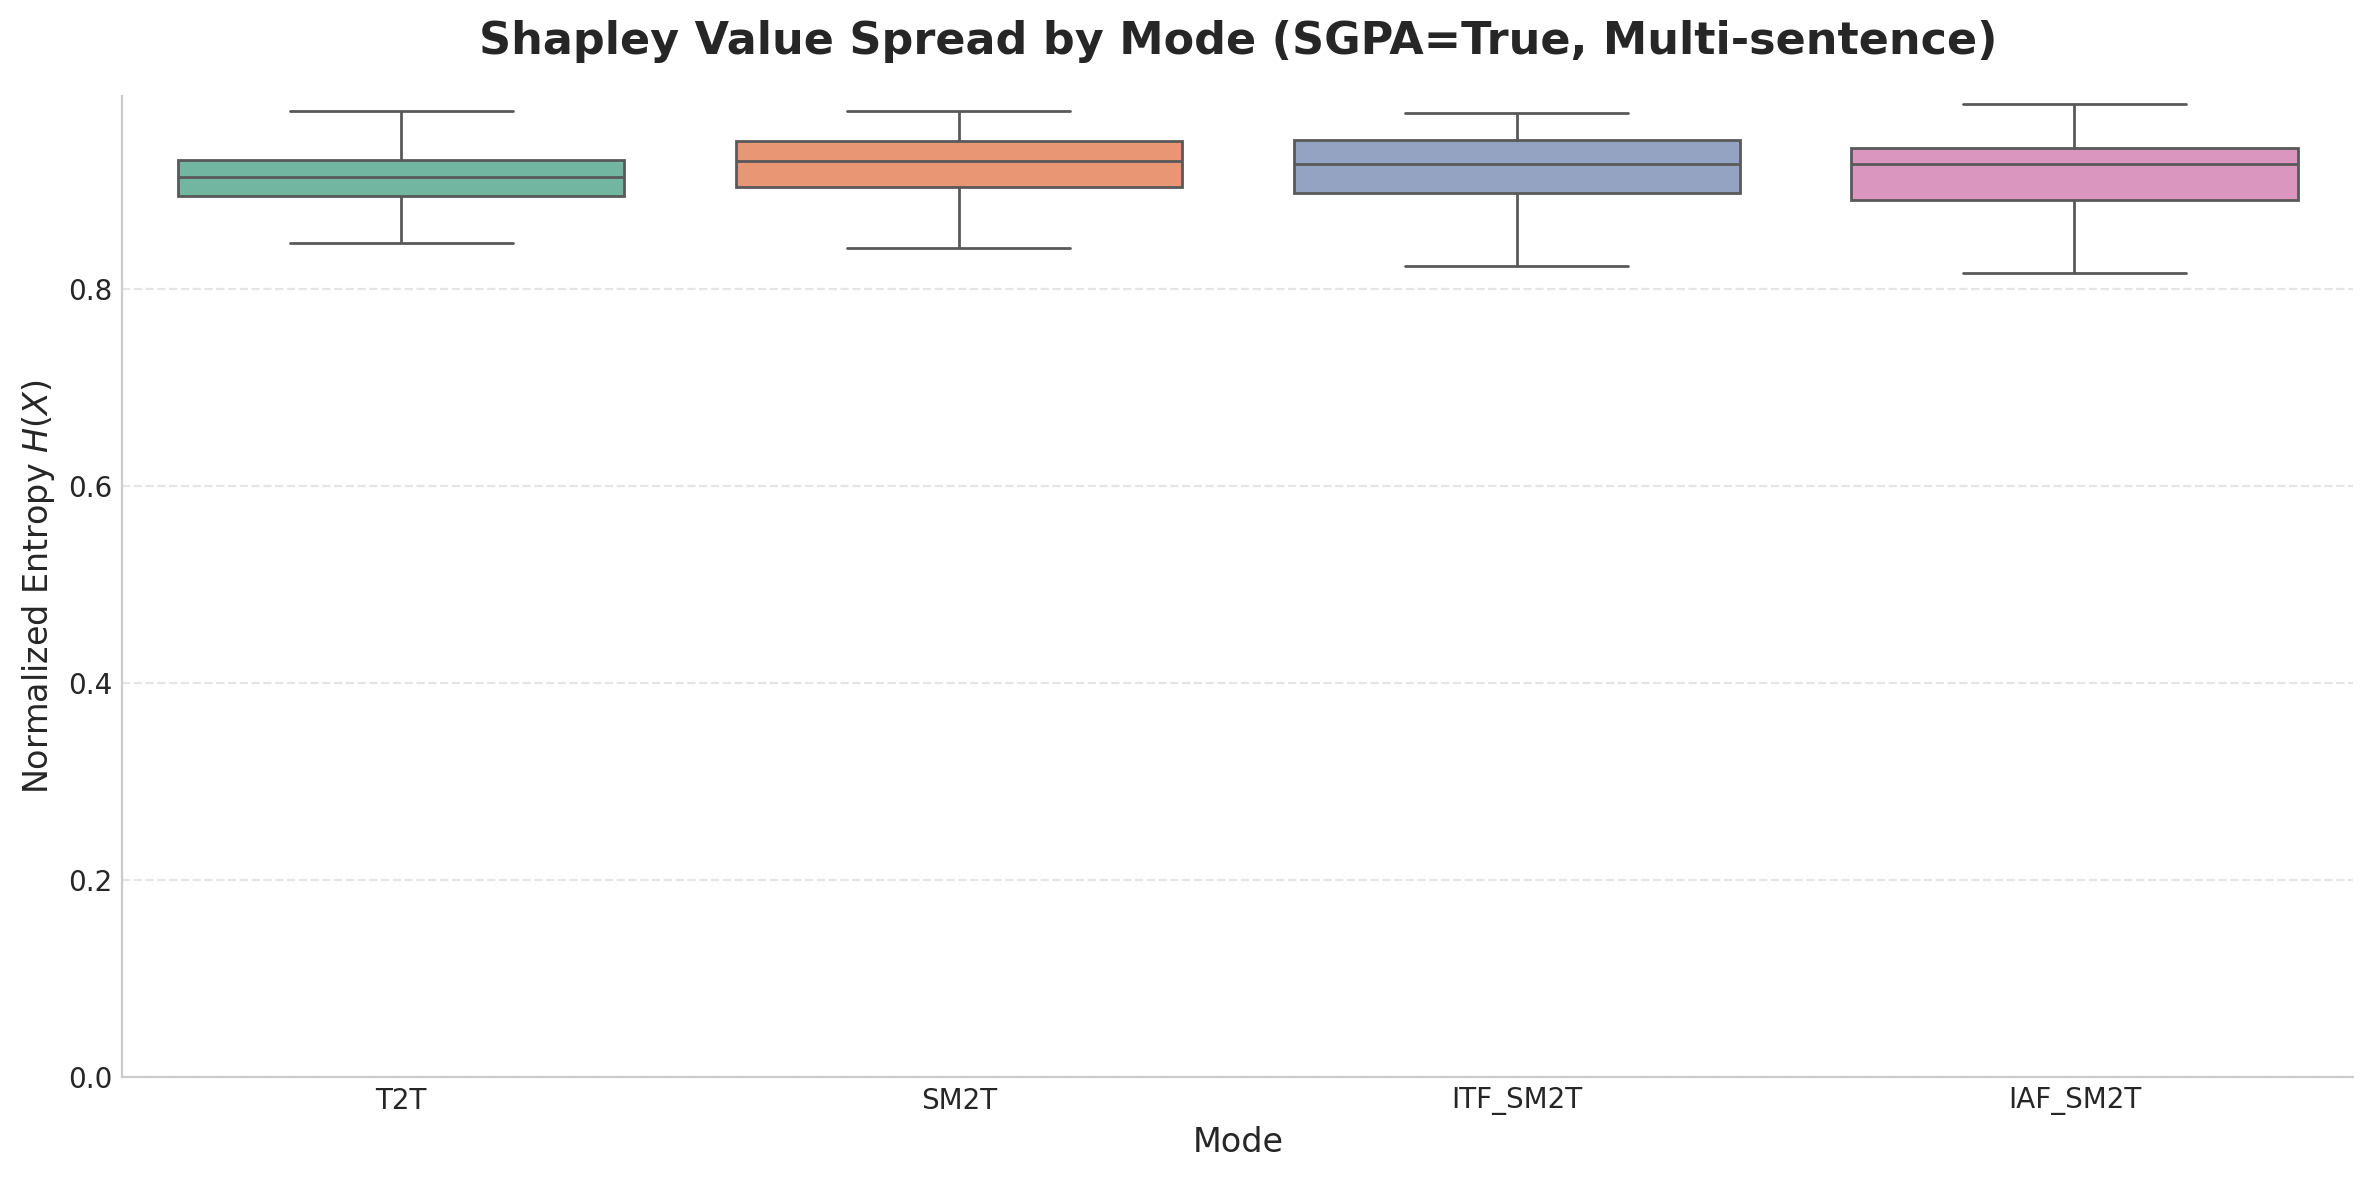

In [20]:
df["sv_entropy"] = df["sv"].apply(calculate_normalized_entropy)
plt.figure(figsize=(12, 6))
ax = sns.boxplot(data=df, x="mode", y="sv_entropy", palette="Set2", showfliers=False)
plt.title("Shapley Value Spread by Mode (SGPA=True, Multi-sentence)", fontsize=16, fontweight="bold", pad=15)
plt.xlabel("Mode", fontsize=12)
plt.ylabel("Normalized Entropy $H(X)$", fontsize=12)
plt.ylim(bottom=0)
sns.despine(top=True, right=True)
ax.tick_params(axis="both", which="both", length=0)
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.tight_layout()
plt.savefig(f"{FIGURES_DIR}/sv_entropy_by_mode.png", bbox_inches="tight", dpi=300)

## Over time / positional bias (token position)


In [ ]:
pos_df = df[["row_index", "mode", "sv"]].copy()
pos_df = pos_df.explode("sv").reset_index(drop=True)
pos_df["sv"] = pos_df["sv"].astype(float)
pos_df["token_pos_idx"] = pos_df.groupby(["mode", "row_index"]).cumcount()
pos_df["max_idx"] = pos_df.groupby(["mode", "row_index"])["token_pos_idx"].transform("max")
pos_df.loc[pos_df["max_idx"] == 0, "max_idx"] = 1
pos_df["normalized_position"] = pos_df["token_pos_idx"] / pos_df["max_idx"]

In [21]:
plot_attribution_trend(pos_df, n_bins=100, legend=True, suffix=" (SGPA=True)")
plt.savefig(f"{FIGURES_DIR}/positional_bias.png", bbox_inches="tight", dpi=300)

NameError: name 'pos_df' is not defined

## Cumulative sum + derivative


In [ ]:
df["sv_cumsum"] = df[SV_COL].apply(np.cumsum)
cumsums = df.groupby(["mode", "row_index"], group_keys=False)[["mode", "row_index", "sv_cumsum"]].apply(
    normalize_lengths
)
plot_df = cumsums.explode("sv_cumsum").reset_index(drop=True)
plot_df["time (tokens)"] = plot_df.groupby(["mode", "row_index"]).cumcount()
plot_df["sv_cumsum"] = plot_df["sv_cumsum"].astype(float)
plot_df["sv_derivative"] = plot_df.groupby(["mode", "row_index"])["sv_cumsum"].diff().fillna(0)

In [ ]:
plot_importance_cumsum_and_derivative(plot_df)
plt.title("Cumulative Shapley Value and Derivative by Mode (SGPA=True)", fontsize=16, fontweight="bold", pad=280)
plt.savefig(f"{FIGURES_DIR}/cumulative_shapley_and_derivative.png", bbox_inches="tight", dpi=300)

# Linguistic analyses (text tokens only)


In [ ]:
plt.figure(figsize=(10, 5))
sns.boxplot(
    data=text_results_df.dropna(subset=["importance"]),
    x="importance",
    y="abs_sv",
    hue="mode",
    showfliers=False,
    palette="Set2",
)
plt.title("|SV| vs Linguistic Importance Level (SGPA=True)", fontsize=14, fontweight="bold")
plt.xlabel("Linguistic importance level (lower = more core)")
plt.ylabel("|SV|")
plt.tight_layout()
plt.savefig(f"{FIGURES_DIR}/abs_sv_vs_linguistic_importance.png", bbox_inches="tight", dpi=300)

In [ ]:
importance_stats = text_results_df.dropna(subset=["importance"]).groupby(["mode", "importance"])[SV_COL].agg(**AGG_DICT)
importance_stats.to_csv(f"{STATS_DIR}/importance_stats.csv")
importance_stats.head(10)

In [ ]:
pos_stats = text_results_df.dropna(subset=["pos"]).groupby(["mode", "pos"])[SV_COL].agg(**AGG_DICT)
pos_stats.to_csv(f"{STATS_DIR}/pos_stats.csv")
top_pos = text_results_df["pos"].value_counts().head(12).index.tolist()
pos_stats.loc[(slice(None), top_pos), :].head(10)

In [ ]:
def match_rate_max_abs_sv_equals_max_children(_df: pd.DataFrame) -> pd.DataFrame:
    """Compute per-mode match rate between argmax(|SV|) and argmax(children)."""
    rows: list[dict] = []
    for (row_index, mode), grp in _df.groupby(["row_index", "mode"], sort=False):
        grp = grp.dropna(subset=["children"]).copy()
        grp = grp[(grp["dep"] != ROOT_DEP) & (grp["pos"] != "PUNCT")]
        if grp.empty:
            continue
        max_sv_row = grp.loc[grp["abs_sv"].idxmax()]
        max_children_row = grp.loc[grp["children"].idxmax()]
        rows.append({"row_index": row_index, "mode": mode, "match": int(max_sv_row["id"] == max_children_row["id"])})
    out = pd.DataFrame(rows)
    if out.empty:
        return out
    return out.groupby("mode")["match"].agg(match_rate="mean", n="size").reset_index()


children_match = match_rate_max_abs_sv_equals_max_children(text_results_df)
children_match.to_csv(f"{STATS_DIR}/match_max_abs_sv_equals_max_children.csv", index=False)
children_match

In [ ]:
def ttests_by_category(
    token_df: pd.DataFrame,
    category_col: str,
    out_csv: str,
    categories: list[str] | None = None,
) -> pd.DataFrame:
    """Run advanced t-tests per category and persist results."""
    token_df = token_df.dropna(subset=[category_col]).copy()
    if categories is None:
        categories = sorted(token_df[category_col].unique().tolist())
    results_list = []
    for cat in categories:
        subset = token_df[token_df[category_col] == cat]
        if subset.empty:
            continue
        r = perform_advanced_ttest(subset, grp_by_cols=["row_index", "mode"], value_col=SV_COL, unstack=["mode"])
        r[category_col] = cat
        results_list.append(r)
    if not results_list:
        return pd.DataFrame()
    out = pd.concat(results_list, ignore_index=True)
    out.to_csv(out_csv, index=False)
    return out


group_ttests = ttests_by_category(text_results_df, category_col="group", out_csv=f"{STATS_DIR}/ttest_by_group.csv")
pos_ttests = ttests_by_category(
    text_results_df, category_col="pos", out_csv=f"{STATS_DIR}/ttest_by_pos.csv", categories=top_pos
)
display(group_ttests[group_ttests["Significant_Adj"]].head(15))
display(pos_ttests[pos_ttests["Significant_Adj"]].head(15))

# Multi-sentence specific analyses (sentences ≠ turns)


In [22]:
nlp_en = get_nlp("en")
docs = list(nlp_en.pipe(df["inputs"].tolist(), batch_size=32))

spacy_sentence_ids = []
for doc in docs:
    sent_ids = np.zeros(len(doc), dtype=int)
    for sid, sent in enumerate(doc.sents):
        for tok in sent:
            sent_ids[tok.i] = sid
    spacy_sentence_ids.append(sent_ids.tolist())

df["spacy_sentence_ids"] = spacy_sentence_ids
df["subword_sentence_id"] = df.apply(lambda row: [row["spacy_sentence_ids"][i] for i in row["stats_mapping"]], axis=1)

sent_map = df[["row_index", "mode", "subword_sentence_id"]].explode("subword_sentence_id").reset_index(drop=True)
sent_map["id"] = sent_map.groupby(["row_index", "mode"]).cumcount()
sent_map = sent_map.rename(columns={"subword_sentence_id": "sentence_id"})

results_df_sent = results_df.merge(sent_map, on=["row_index", "mode", "id"], how="left")
if results_df_sent["sentence_id"].isna().any():
    raise RuntimeError("Missing sentence_id for some token rows.")
results_df_sent["abs_sv"] = results_df_sent[SV_COL].abs()
results_df_sent.head(2)

,prompt,row_index,mode,language,token,id,sv,dep,pos,children,...,abs_sv,is_audio,is_text,T2*,S2T,S2S,S2*,*2T,*2S,sentence_id
0,Write a song about innovation with a positive ...,63,T2T,en,Write,0,0.049724,ROOT,VERB,2,...,0.049724,False,True,True,False,False,False,True,False,0
1,Write a song about innovation with a positive ...,63,T2T,en,a,1,0.011677,det,DET,0,...,0.011677,False,True,True,False,False,False,True,False,0


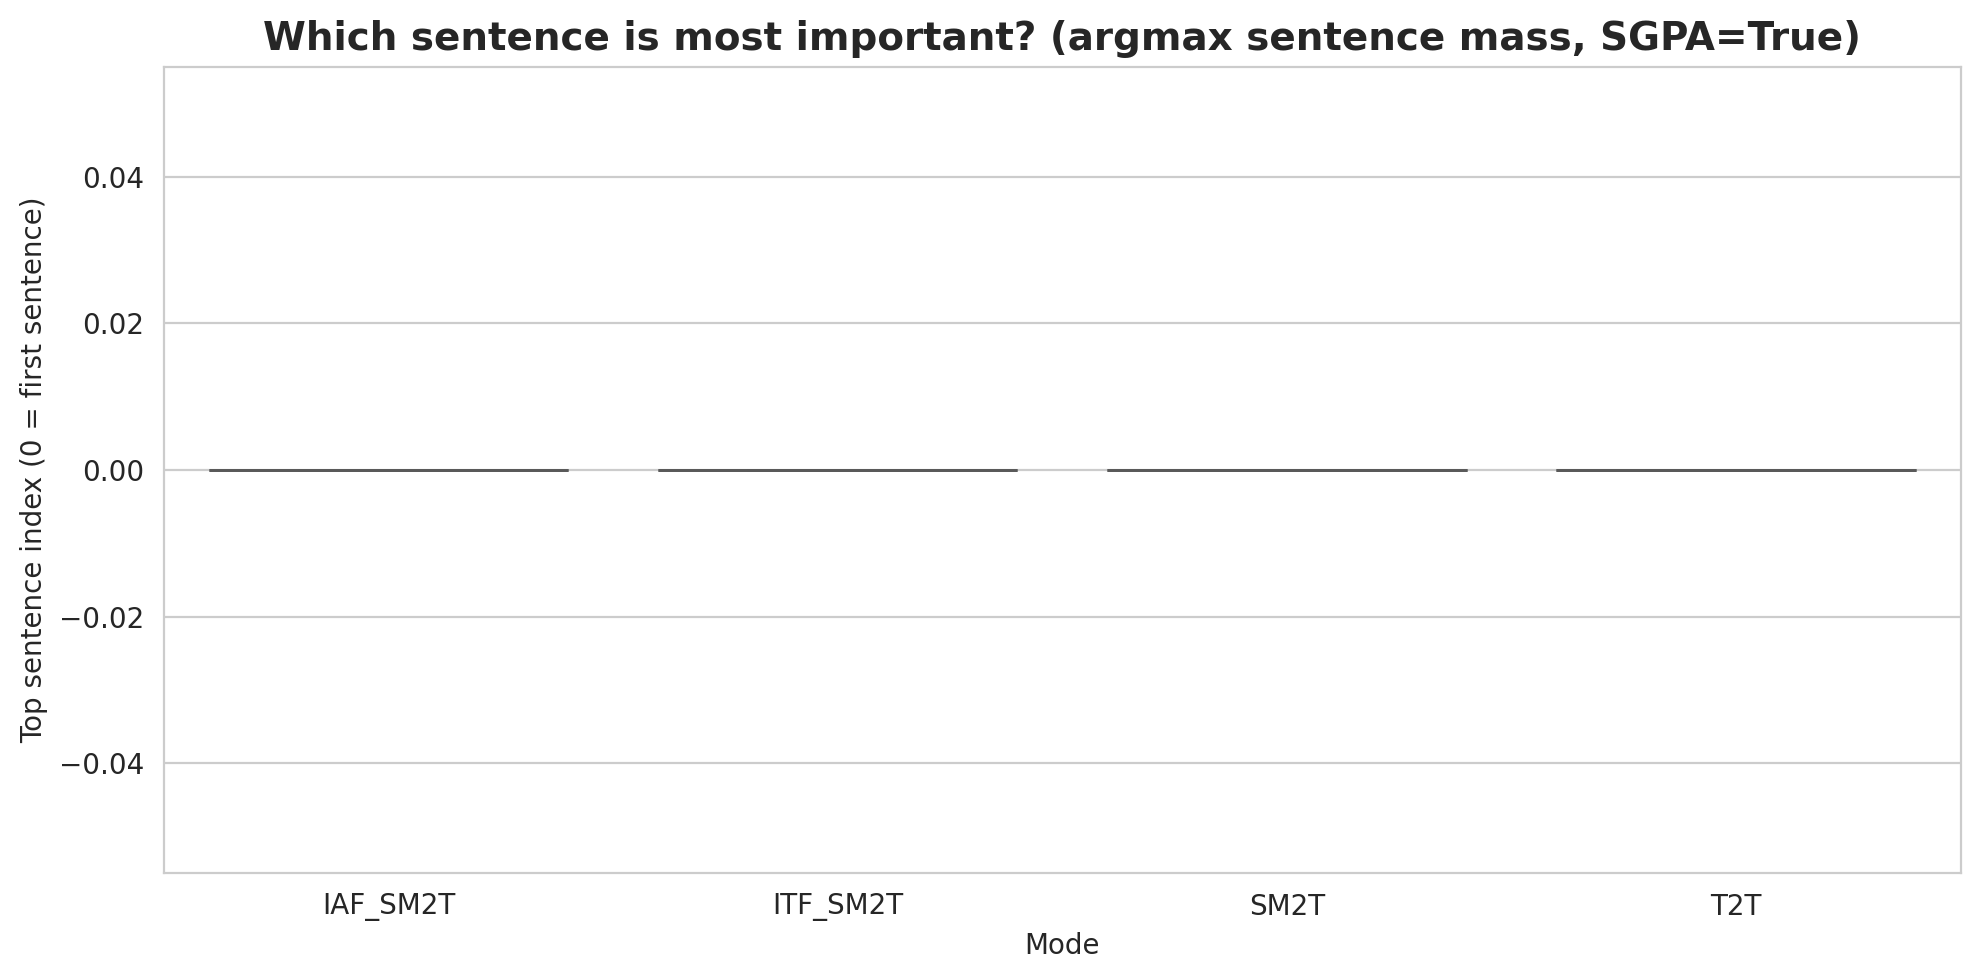

In [23]:
sent_mass = (
    results_df_sent.groupby(["row_index", "mode", "sentence_id"], as_index=False)["abs_sv"]
    .sum()
    .rename(columns={"abs_sv": "sent_abs_mass"})
)
sent_mass["total_abs_mass"] = sent_mass.groupby(["row_index", "mode"])["sent_abs_mass"].transform("sum")
sent_mass["sent_share"] = sent_mass["sent_abs_mass"] / sent_mass["total_abs_mass"].replace(0, np.nan)

top_sent = (
    sent_mass.sort_values(["row_index", "mode", "sent_share"], ascending=[True, True, False])
    .groupby(["row_index", "mode"], as_index=False)
    .head(1)
)
top_sent = top_sent.rename(columns={"sentence_id": "top_sentence_id", "sent_share": "top_sentence_share"})
top_sent.to_csv(f"{STATS_DIR}/top_sentence_by_mass.csv", index=False)

plt.figure(figsize=(10, 5))
sns.boxplot(data=top_sent, x="mode", y="top_sentence_id", showfliers=False, palette="Set2")
plt.title("Which sentence is most important? (argmax sentence mass, SGPA=True)", fontsize=14, fontweight="bold")
plt.xlabel("Mode")
plt.ylabel("Top sentence index (0 = first sentence)")
plt.tight_layout()
plt.savefig(f"{FIGURES_DIR}/top_sentence_index_by_mode.png", bbox_inches="tight", dpi=300)

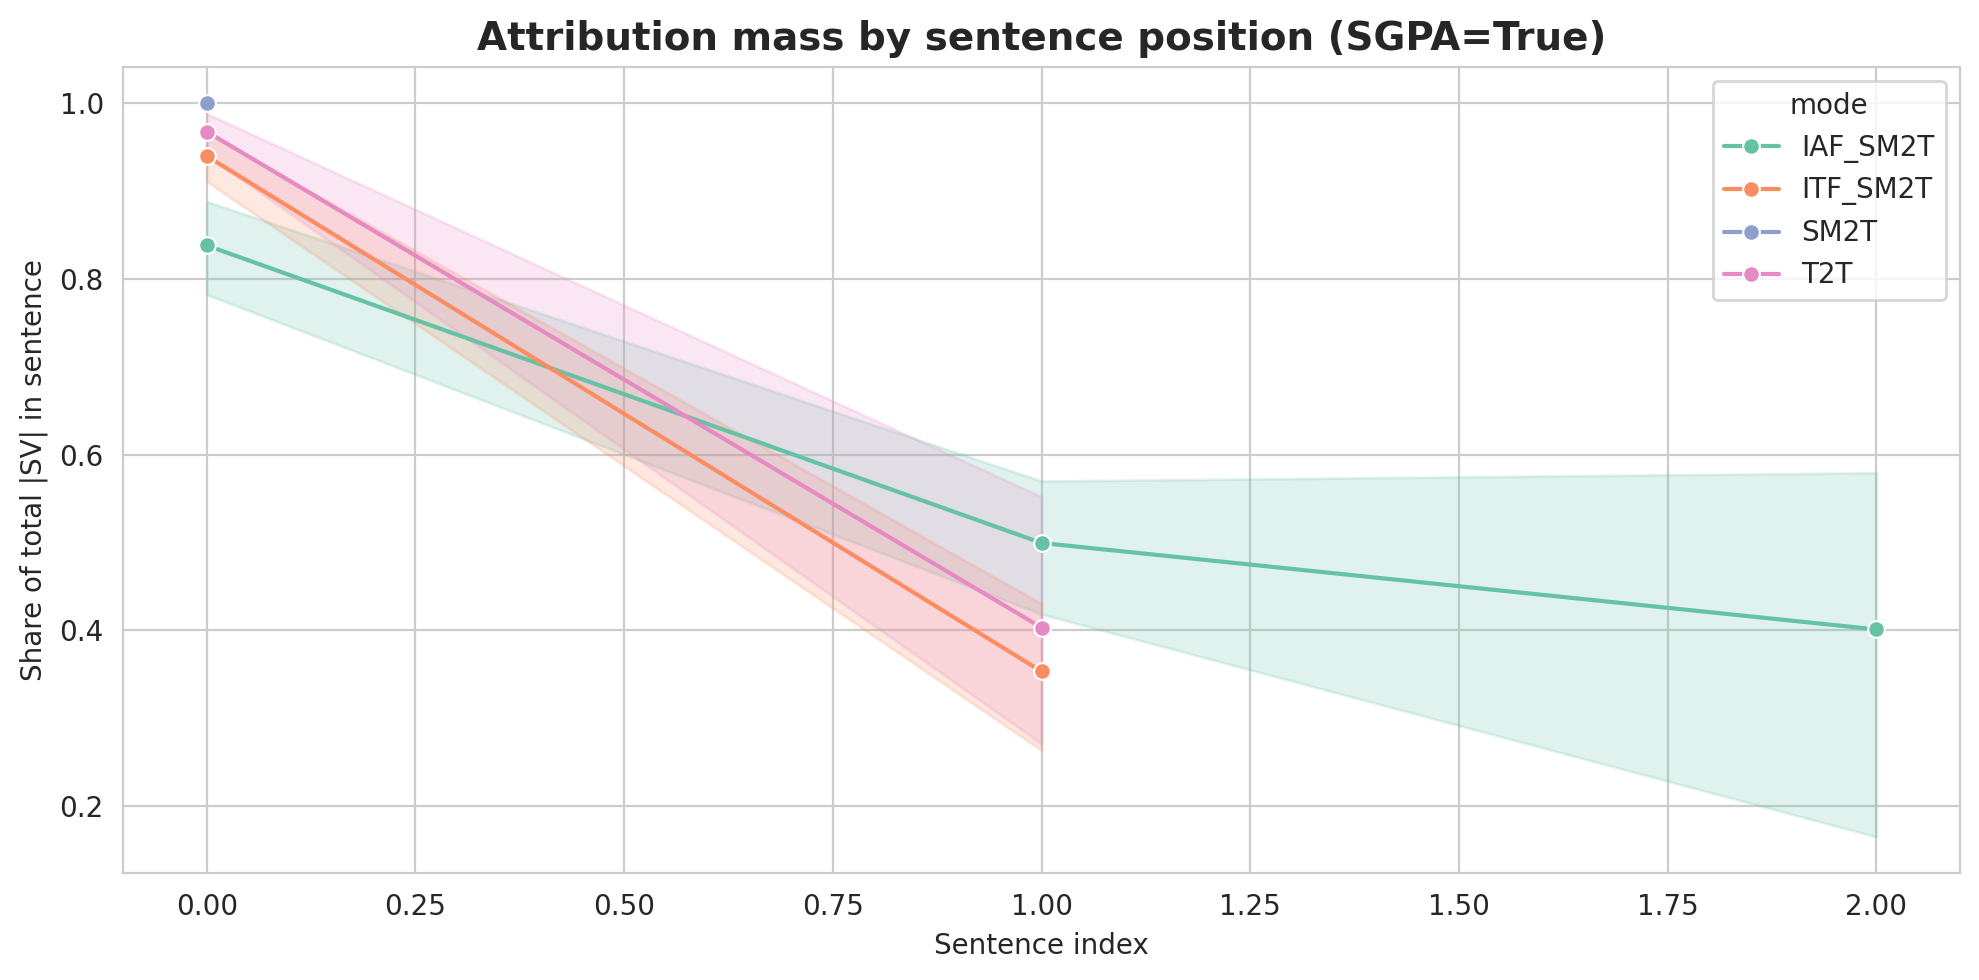

In [24]:
MAX_SENTENCES_TO_SHOW = 10
sent_bias = sent_mass[sent_mass["sentence_id"] < MAX_SENTENCES_TO_SHOW].copy()
sent_bias = sent_bias.rename(columns={"sentence_id": "sentence_idx"})

plt.figure(figsize=(10, 5))
sns.lineplot(
    data=sent_bias, x="sentence_idx", y="sent_share", hue="mode", errorbar=("ci", 95), marker="o", palette="Set2"
)
plt.title("Attribution mass by sentence position (SGPA=True)", fontsize=14, fontweight="bold")
plt.xlabel("Sentence index")
plt.ylabel("Share of total |SV| in sentence")
plt.tight_layout()
plt.savefig(f"{FIGURES_DIR}/sentence_position_bias.png", bbox_inches="tight", dpi=300)

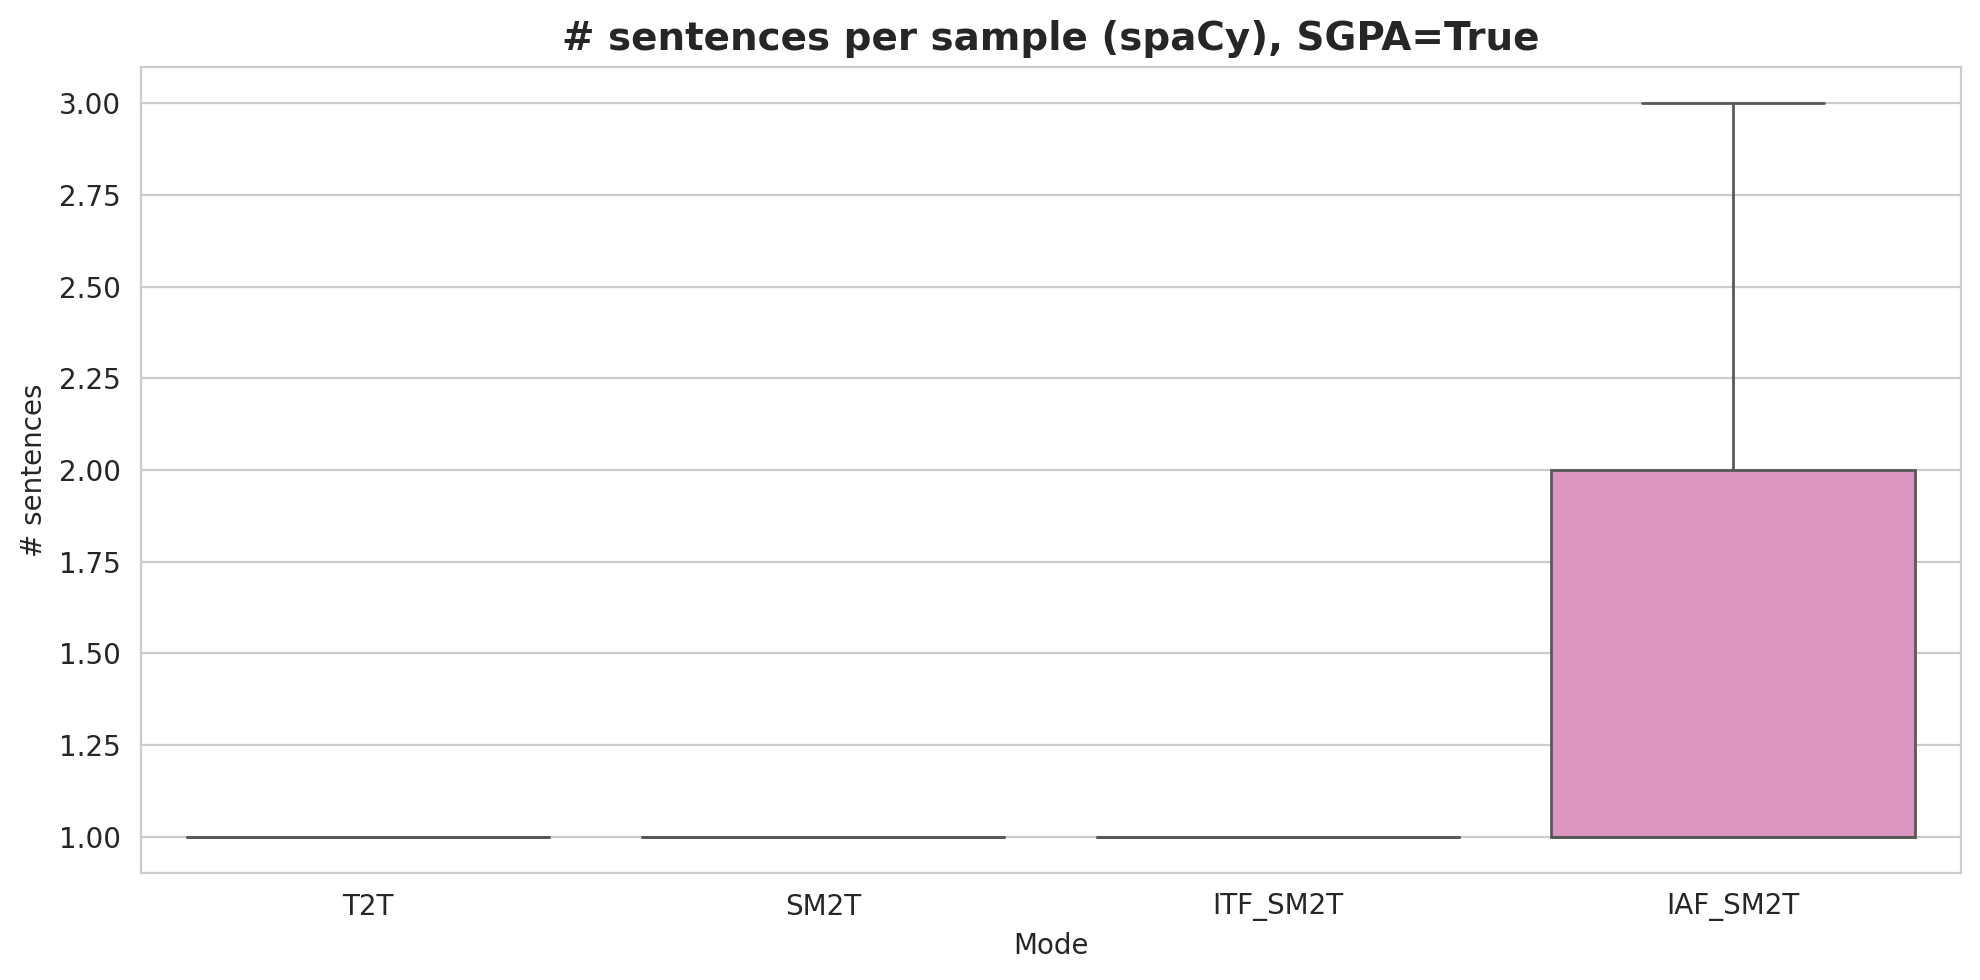

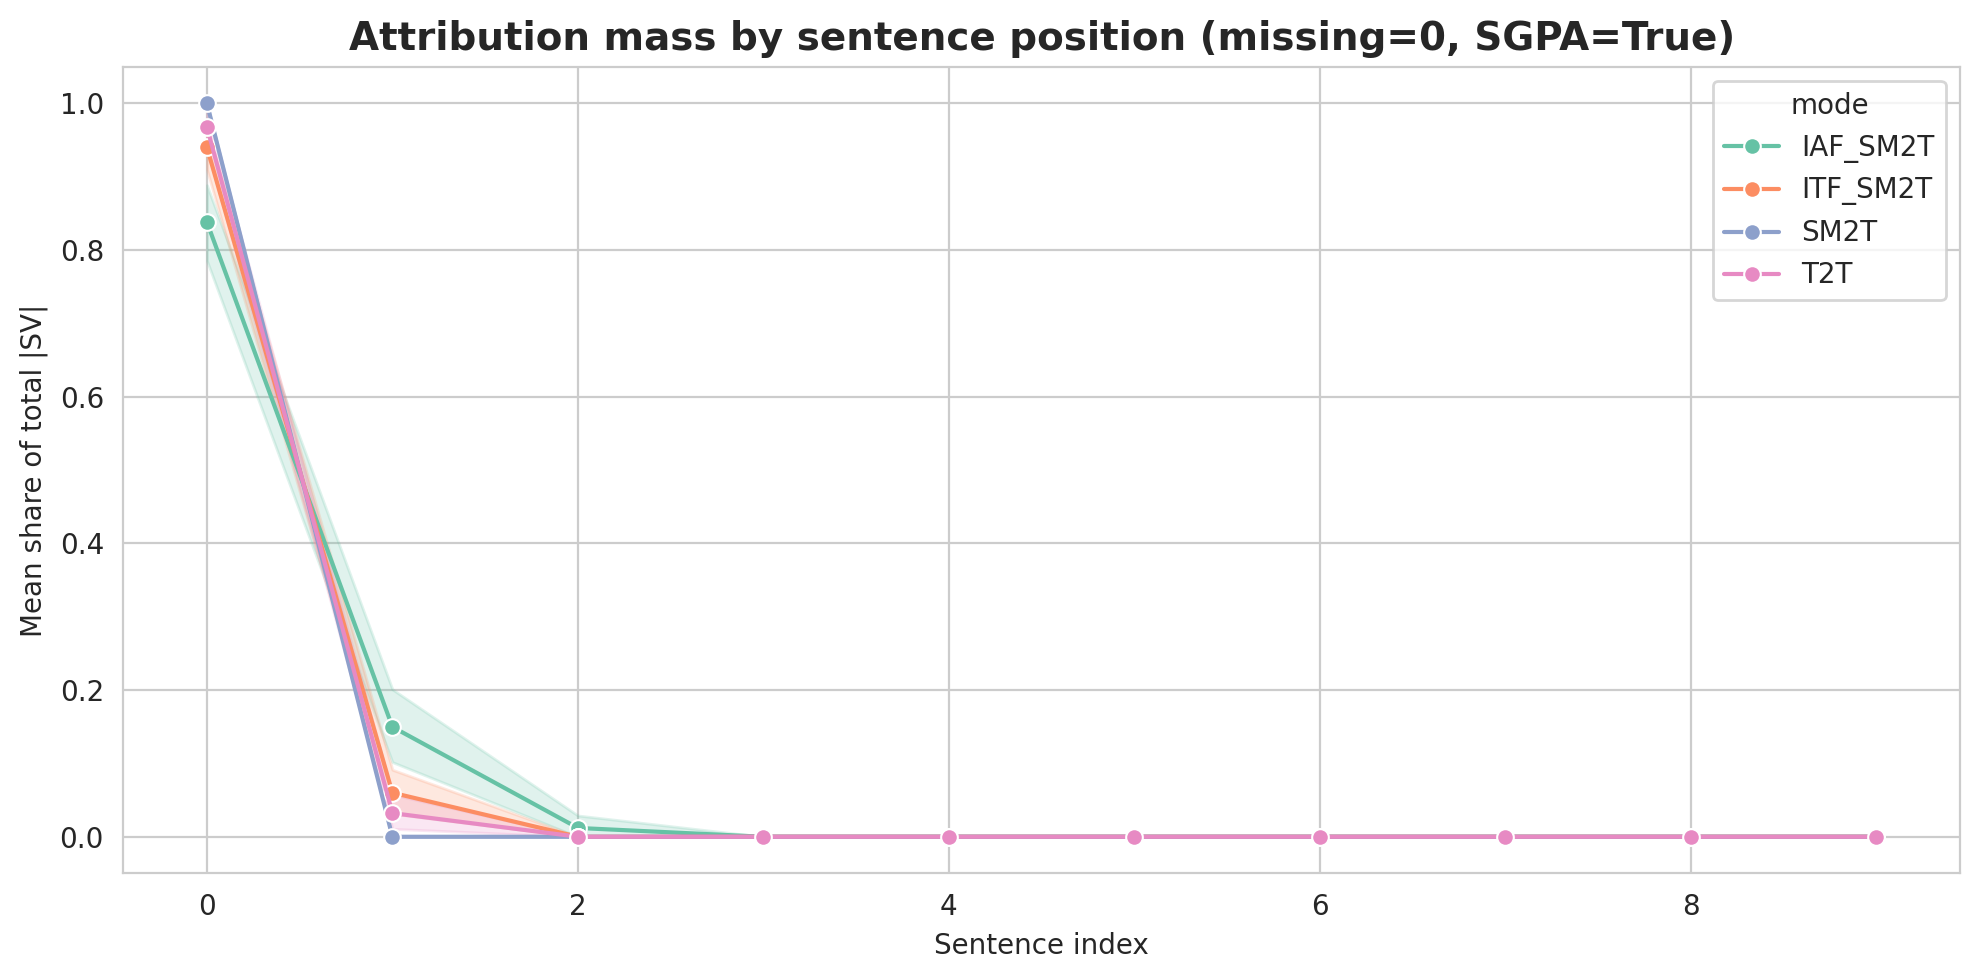

In [25]:
df["n_sentences"] = df["spacy_sentence_ids"].apply(
    lambda ids: int(max(ids) + 1) if isinstance(ids, list) and len(ids) else 0
)
sentence_counts = df[["row_index", "mode", "n_sentences"]].copy()
sentence_counts.to_csv(f"{STATS_DIR}/n_sentences_by_sample.csv", index=False)

plt.figure(figsize=(10, 5))
sns.boxplot(data=sentence_counts, x="mode", y="n_sentences", showfliers=False, palette="Set2")
plt.title("# sentences per sample (spaCy), SGPA=True", fontsize=14, fontweight="bold")
plt.xlabel("Mode")
plt.ylabel("# sentences")
plt.tight_layout()
plt.savefig(f"{FIGURES_DIR}/n_sentences_by_mode.png", bbox_inches="tight", dpi=300)

sent_pivot = sent_mass.pivot_table(
    index=["row_index", "mode"], columns="sentence_id", values="sent_share", aggfunc="first"
)
sent_pivot = sent_pivot.reindex(columns=list(range(MAX_SENTENCES_TO_SHOW)), fill_value=0).fillna(0)
sent_pivot = sent_pivot.reset_index().melt(
    id_vars=["row_index", "mode"], var_name="sentence_idx", value_name="sent_share"
)
sent_pivot["sentence_idx"] = sent_pivot["sentence_idx"].astype(int)

plt.figure(figsize=(10, 5))
sns.lineplot(
    data=sent_pivot, x="sentence_idx", y="sent_share", hue="mode", errorbar=("ci", 95), marker="o", palette="Set2"
)
plt.title("Attribution mass by sentence position (missing=0, SGPA=True)", fontsize=14, fontweight="bold")
plt.xlabel("Sentence index")
plt.ylabel("Mean share of total |SV|")
plt.tight_layout()
plt.savefig(f"{FIGURES_DIR}/sentence_position_bias_missing0.png", bbox_inches="tight", dpi=300)

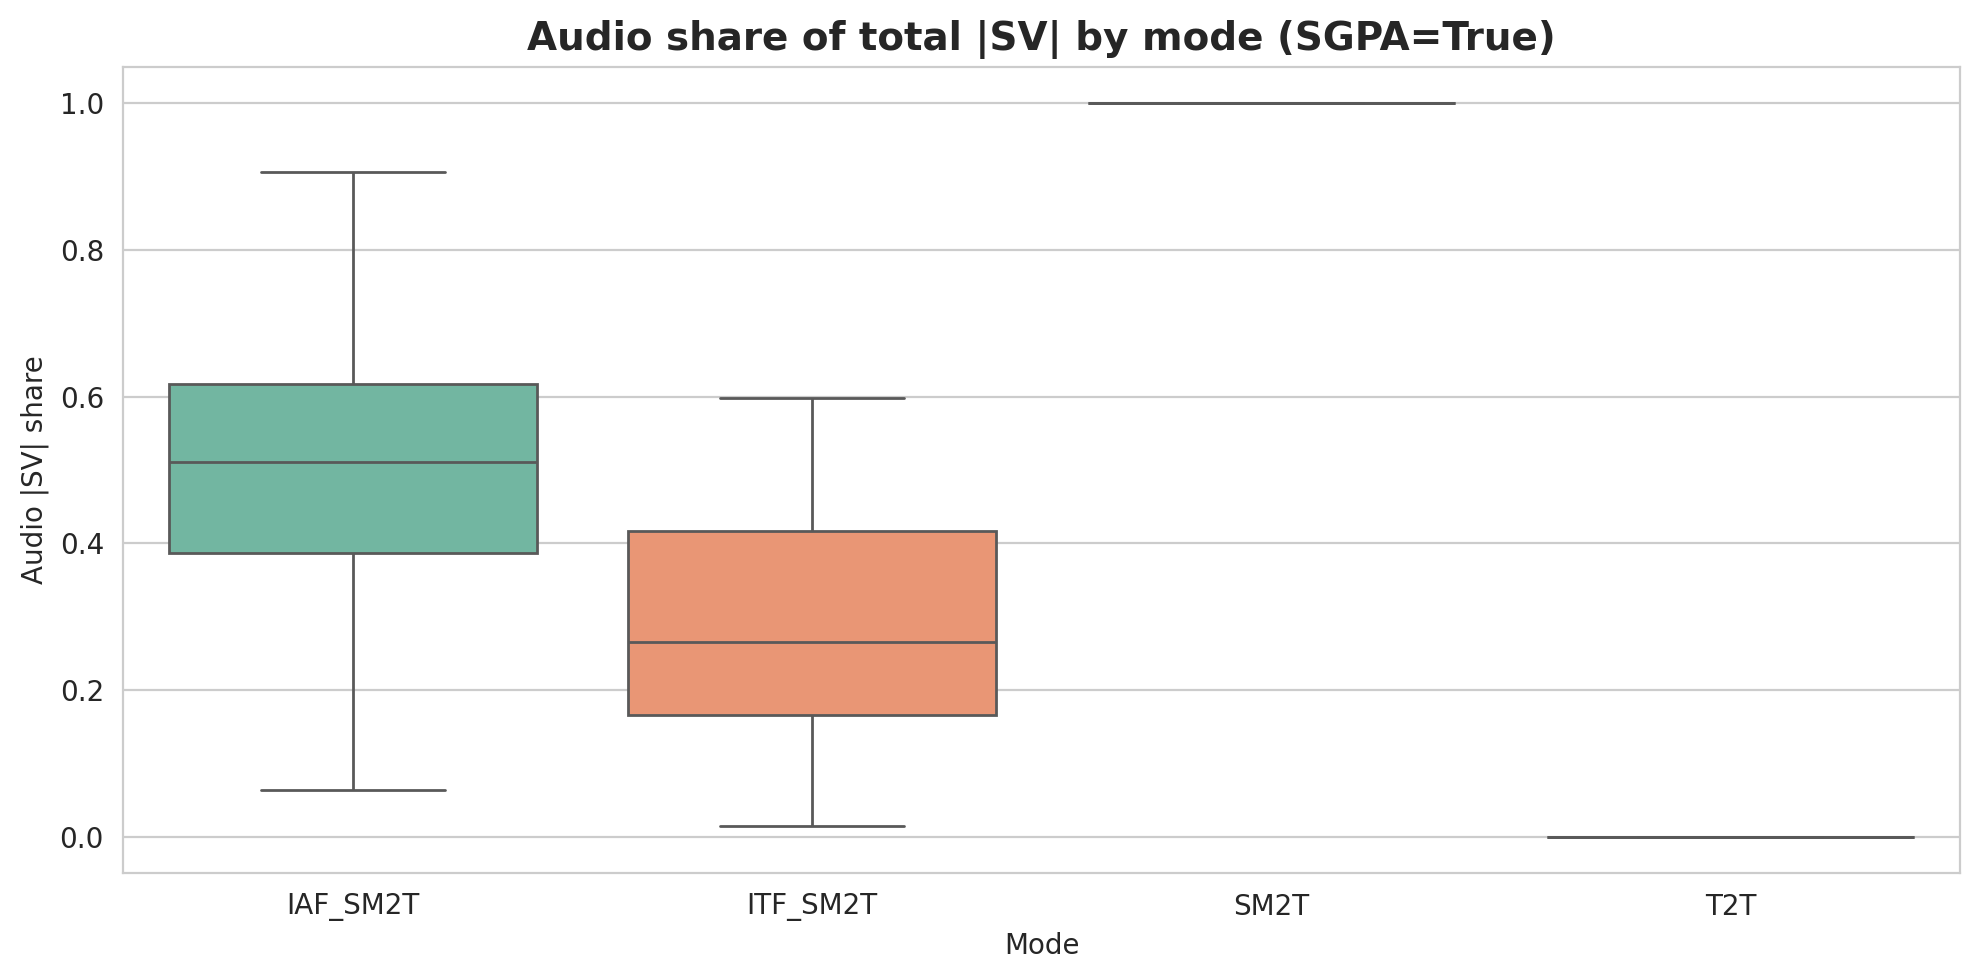

In [26]:
results_df_sent["is_audio"] = results_df_sent["token"].astype(str).str.contains(r"AUDIO_", regex=True)
results_df_sent["is_text"] = ~results_df_sent["is_audio"]

audio_share = (
    results_df_sent.groupby(["row_index", "mode"], as_index=False)
    .apply(
        lambda g: pd.Series(
            {
                "audio_abs_mass": g.loc[g["is_audio"], "abs_sv"].sum(),
                "text_abs_mass": g.loc[g["is_text"], "abs_sv"].sum(),
                "total_abs_mass": g["abs_sv"].sum(),
            }
        )
    )
    .reset_index(drop=True)
)
audio_share["audio_share"] = audio_share["audio_abs_mass"] / audio_share["total_abs_mass"].replace(0, np.nan)
audio_share.to_csv(f"{STATS_DIR}/audio_share_by_sample.csv", index=False)

plt.figure(figsize=(10, 5))
sns.boxplot(data=audio_share, x="mode", y="audio_share", showfliers=False, palette="Set2")
plt.title("Audio share of total |SV| by mode (SGPA=True)", fontsize=14, fontweight="bold")
plt.xlabel("Mode")
plt.ylabel("Audio |SV| share")
plt.tight_layout()
plt.savefig(f"{FIGURES_DIR}/audio_share_by_mode.png", bbox_inches="tight", dpi=300)

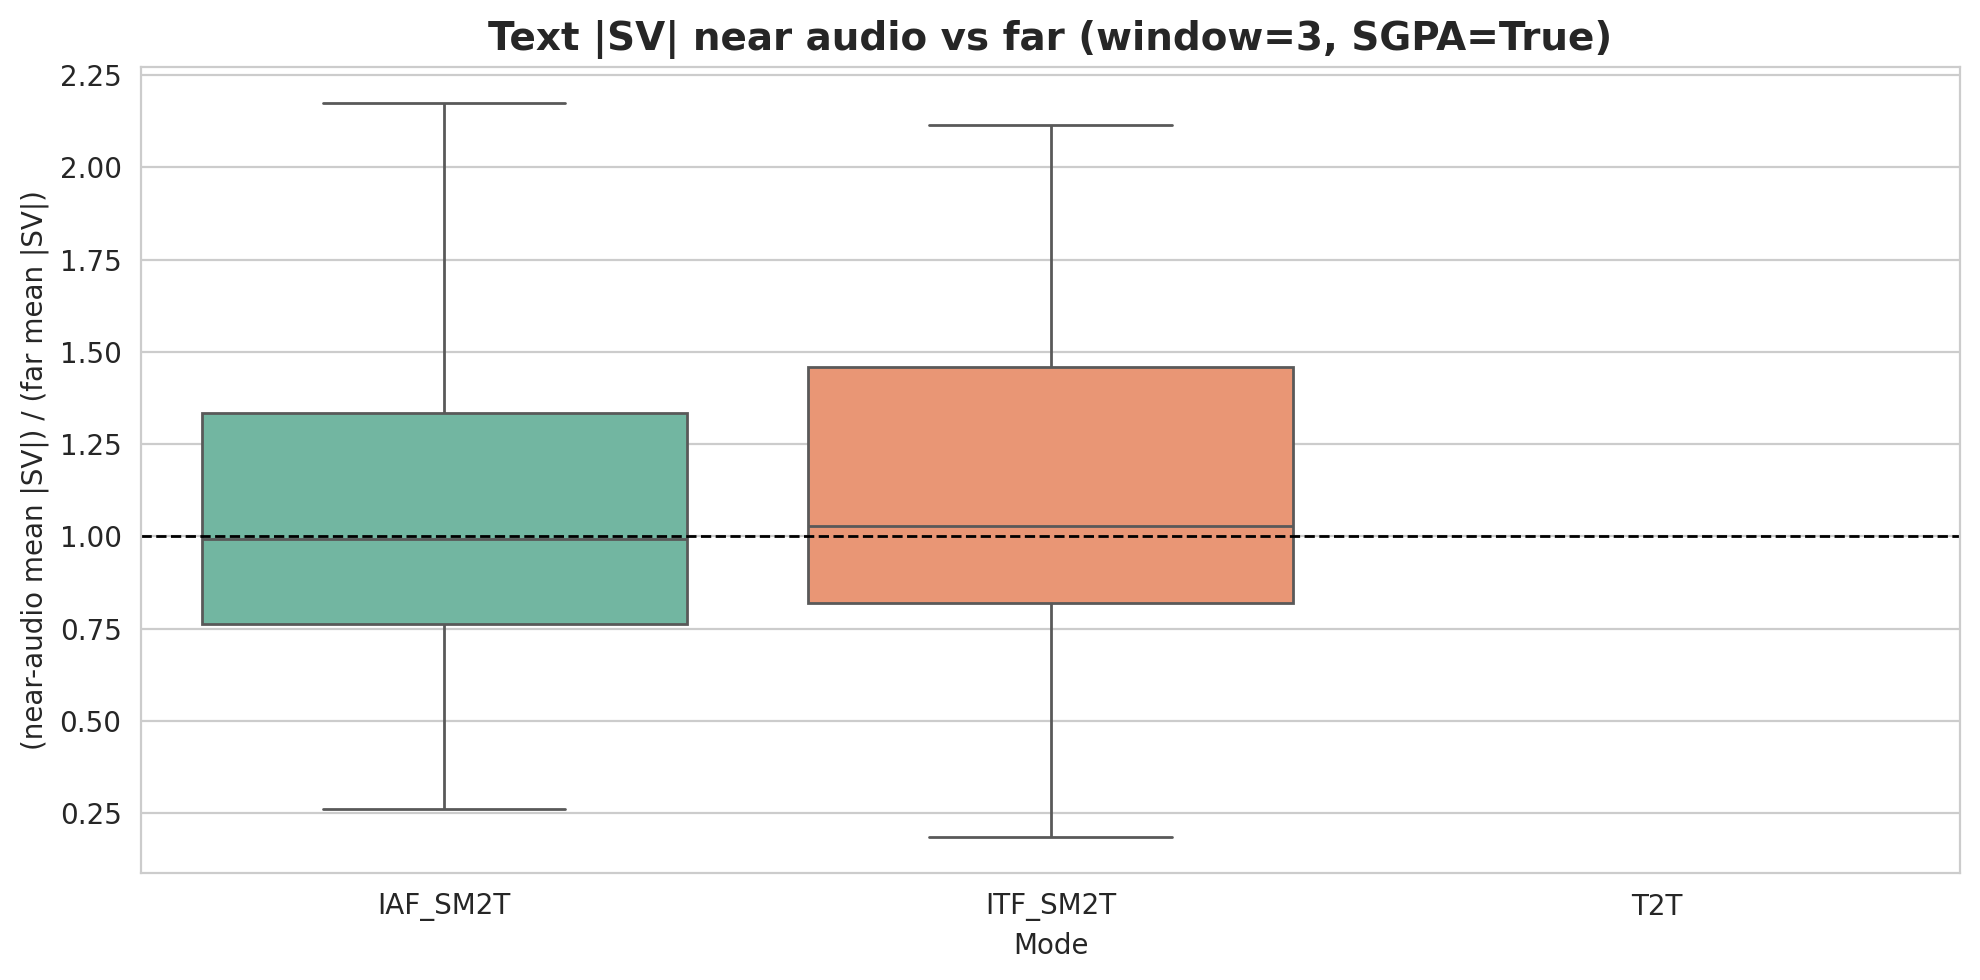

In [27]:
WINDOW = 3
t = results_df_sent.sort_values(["row_index", "mode", "id"]).reset_index(drop=True).copy()
t["audio_idx"] = (
    t.groupby(["row_index", "mode"])["is_audio"]
    .apply(lambda s: s.astype(int).rolling(2 * WINDOW + 1, center=True, min_periods=1).max())
    .reset_index(level=[0, 1], drop=True)
)
t["near_audio"] = t["audio_idx"] > 0

text_only = t[t["is_text"]].copy()
near_far = (
    text_only.groupby(["row_index", "mode"], as_index=False)
    .apply(
        lambda g: pd.Series(
            {
                "near_mean_abs_sv": g.loc[g["near_audio"], "abs_sv"].mean(),
                "far_mean_abs_sv": g.loc[~g["near_audio"], "abs_sv"].mean(),
            }
        )
    )
    .reset_index(drop=True)
)
near_far["near_over_far"] = near_far["near_mean_abs_sv"] / near_far["far_mean_abs_sv"]
near_far.to_csv(f"{STATS_DIR}/near_audio_ratio_by_sample.csv", index=False)

plt.figure(figsize=(10, 5))
sns.boxplot(data=near_far, x="mode", y="near_over_far", showfliers=False, palette="Set2")
plt.axhline(1.0, color="black", linewidth=1, linestyle="--")
plt.title(f"Text |SV| near audio vs far (window={WINDOW}, SGPA=True)", fontsize=14, fontweight="bold")
plt.xlabel("Mode")
plt.ylabel("(near-audio mean |SV|) / (far mean |SV|)")
plt.tight_layout()
plt.savefig(f"{FIGURES_DIR}/near_audio_ratio.png", bbox_inches="tight", dpi=300)